# Method Comparison — Tree Oracle Simulator

Compare current methods on `tree_oracle_sim.json` outputs.
**Real-cost only** (`*_speedup_real`); ratio-mode columns are no longer produced.

**Methods (50% gap goal):**
- Baselines: `single:eagle3`, `single:suffix`
- Hybrid baselines: `hybrid_e3:t` (paper-faithful), `hybrid_e3_sfx:F:T:N:t` (custom suffix params, when present)
- Extension oracles: `extension_oracle`, `extension_prune_pt_oracle:t`, `extension_sfx_oracle:F:T:N`
- Deployable extension: `extension`, `extension_sfx:F:T:N`, `extension_prune_pt:t`, `extension_hybrid:t`

**Forbidden methods are filtered out** (per `project_50pct_gap_goal.md` rules — 2026-04-27):
- `extension_oracle_path`, `extension_hybrid_perfect_oracle*`
- `extension_dual_method*`, `extension_pure_sfx*`
- `extension_dmsfx*`, `extension_by_*` (deprecated)
- These methods were removed from the simulator and are NOT displayed even when present in old JSONs.

Cross-config comparison: each method picks its OWN best (s, k, B, threshold) — never
constrained to a shared reslice (per `feedback_method_optimum_independent.md`).

In [61]:
import json
import re
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


In [62]:
# ========== CONFIG ==========
# Specify ONLY the workload. The notebook auto-finds each method's best
# (s, k, B, F, T, N, threshold) combo across ALL sims of that workload.

# ---- MODEL_PRESET: toggle by uncommenting the desired line ----
# Driven the SIM_DIRS, MODEL_LATENCY, and the PROPOSER_LABEL displayed in
# charts/tables. Only ONE line should be uncommented.
MODEL_PRESET = "qwen3_14b"      # EAGLE3 — Qwen3-14B + AngelSlim eagle3 draft
# MODEL_PRESET = "qwen35_9b"    # MTP — Qwen3.5-9B (built-in MTP head; eagle3_* fields in raw oracle log are MTP data)

WORKLOAD = "spider_sql"

# Hide families from charts (toggle to focus on subset).
# When both False (default), every enrolled family is shown.
HIDE_DRAFT_MODEL = False  # hides single:draft_model + all *_dm* families
HIDE_EAGLE3      = False  # hides single:eagle3 + every eagle3-backbone family

# Speedup metric: 'real' (latency-calibrated), or 'r0.05' / 'r0.1' / 'r0.2' /
# 'r0.3' / 'r0.5' (assumes draft_step_cost / verify_step_cost = r).
# Same toggle is honored by the variant cell at the bottom.
SPEEDUP_METRIC = 'real'
_METRIC_SUFFIX = f'_speedup_{SPEEDUP_METRIC}'   # column suffix in budget_sweep entries

# ---- Preset-driven paths + labels ----
if MODEL_PRESET == "qwen35_9b":
    # MTP — Qwen3.5-9B captures live in explorations_qwen35_9b/. The proposer
    # is the built-in MTP head; raw oracle log labels it "eagle3" (see the
    # project_eagle_label_means_mtp memory) but for display we render as MTP.
    SIM_DIRS = [
        Path("../results/explorations_qwen35_9b"),
    ]
    # Real measured latency lives at qwen35_9b.json once measure_eagle3_cost
    # finishes; until then fall back to the placeholder (copy of qwen3_14b)
    # with a clear warning. Numbers are then NOT calibrated for Qwen3.5.
    _real_latency = Path("../config/latency/qwen35_9b.json")
    _placeholder  = Path("../config/latency/qwen35_9b_placeholder.json")
    if _real_latency.exists():
        MODEL_LATENCY = _real_latency
    else:
        MODEL_LATENCY = _placeholder
        print(f"[WARN] {_real_latency} not yet measured — using placeholder "
              f"({_placeholder.name}, copy of qwen3_14b). Speedup numbers "
              f"are NOT calibrated for Qwen3.5; rerun once measurement is done.")
    PROPOSER_LABEL = "MTP"
elif MODEL_PRESET == "qwen3_14b":
    SIM_DIRS = [
        Path("../results/explorations"),
    ]
    MODEL_LATENCY = Path("../config/latency/qwen3_14b.json")
    PROPOSER_LABEL = "EAGLE3"
else:
    raise ValueError(f"Unknown MODEL_PRESET={MODEL_PRESET!r}; "
                     "valid: 'qwen3_14b', 'qwen35_9b'")

# Auto-discover sim JSONs
SIM_FILES = {}  # name -> (path, info_dict)

def _parse_filename(stem):
    info = {"workload": None, "steps": None, "topk": None, "budget": None}
    m = re.search(r"(swebench|specbench|bfcl_v[34]|longbench_lcc|longbench_repobench|lcc|repobench|magicoder|spider_sql|wildchat|humaneval|livecodebench)", stem)
    if m: info["workload"] = m.group(1)
    m = re.search(r"s(\d+)k(\d+)", stem)
    if m: info["steps"] = int(m.group(1)); info["topk"] = int(m.group(2))
    return info

def _is_sim_json(path):
    try:
        with open(path) as f:
            d = json.load(f)
        return ("latency" in d and isinstance(d["latency"], dict)
                and "budget_sweep" in d["latency"])
    except Exception:
        return False

for d in SIM_DIRS:
    if not d.exists(): continue
    candidates = list(d.glob("*.json")) + list(d.glob("*/tree_oracle_sim.json"))
    for p in candidates:
        if not _is_sim_json(p): continue
        stem = p.parent.name if p.name == "tree_oracle_sim.json" else p.stem
        info = _parse_filename(stem)
        SIM_FILES[stem] = (str(p), info)

# Filter to selected workload
WORKLOAD_SIMS = {k: v for k, v in SIM_FILES.items()
                 if v[1]["workload"] == WORKLOAD}
if not WORKLOAD_SIMS:
    raise RuntimeError(f"No sim JSONs found for workload={WORKLOAD!r} under {SIM_DIRS}.\n"
                       f"Have workloads: {sorted({v[1]['workload'] for v in SIM_FILES.values()})}")

print(f"Preset:   {MODEL_PRESET}  (proposer display label: {PROPOSER_LABEL})")
print(f"Workload: {WORKLOAD}")
print(f"Discovered sims ({len(WORKLOAD_SIMS)}):")
for k in sorted(WORKLOAD_SIMS):
    info = WORKLOAD_SIMS[k][1]
    sk = f"s={info['steps']} k={info['topk']}" if info['steps'] else "(no s/k tag)"
    print(f"  {k}  [{sk}]")

# Load latency config (vanilla_step_ms used by step-cost chart)
vanilla_ms = float(json.load(open(MODEL_LATENCY))["vanilla_step_ms"])
print(f"\nvanilla_step_ms = {vanilla_ms:.3f} ms (from {MODEL_LATENCY})")


Preset:   qwen3_14b  (proposer display label: EAGLE3)
Workload: spider_sql
Discovered sims (4):
  sim_spider_sql_s2k8_full  [s=2 k=8]
  sim_spider_sql_s4k4_full  [s=4 k=4]
  sim_spider_sql_s6k16_full  [s=6 k=16]
  sim_spider_sql_s8k16_full  [s=8 k=16]

vanilla_step_ms = 40.754 ms (from ../config/latency/qwen3_14b.json)


## 1. Method Taxonomy

Classify each method into a family + flag whether it's allowed for the 50% gap claim.

In [63]:
# Method classification: family + display label + hyperparam extractor + colors.
# Current spec (2026-04-29): 8 families. Forbidden methods filtered.

FORBIDDEN_PATTERNS = [
    r"^extension_oracle_path$",
    r"^extension_hybrid_perfect_oracle",
    r"^extension_sfx_backbone",
    r"^extension_anchor",
    r"^extension_hybrid",          # removed from spec
    r"^extension_hybrid_prune_pt",
    r"^extension_dual_method",
    r"^extension_pure_sfx",
    r"^extension_dmsfx",
    r"^extension_by_count_score",  # removed from spec
    r"^extension_by_pathprob",
    r"^extension_by_pt",
    r"^extension_joint_score",     # removed from spec
    r"^extension_prune_pt_oracle", # removed from spec
    r"^hybrid_e3_sfx",              # legacy variant
]

def is_forbidden(name):
    return any(re.match(p, name) for p in FORBIDDEN_PATTERNS)

def family(name):
    # MTP variants — Qwen3.5-9B captures (proposer is the built-in MTP head;
    # raw oracle log labels it "eagle3", run_tree_oracle_sim --proposer-label mtp
    # rewrites the output to "mtp"). Match BEFORE the eagle3 rules.
    if name == "mtp" or name.startswith("single:mtp"):
        return "single:mtp"
    if name.startswith("hybrid_oracle_mtp"):
        return "hybrid_oracle_mtp"
    if name.startswith("hybrid_mtp"):
        return "hybrid_mtp"
    if name == "eagle3" or name.startswith("single:eagle3"):
        return "single:eagle3"
    if (name == "suffix" or name.startswith("single:suffix")
            or re.match(r"^suffix_f[\d.]", name)):
        return "single:suffix"
    if name == "draft_model" or name.startswith("single:draft_model"):
        return "single:draft_model"
    if name.startswith("hybrid_dm_oracle"):
        return "hybrid_dm_oracle"
    if name.startswith("hybrid_dm"):
        return "hybrid_dm"
    if name.startswith("hybrid_oracle"):
        return "hybrid_oracle"
    if name.startswith("hybrid_e3"):
        return "hybrid_e3"
    # extension_dm_* must come BEFORE extension_*  (more specific prefix)
    if name.startswith("extension_dm_by_count"):
        return "extension_dm_by_count"
    if name.startswith("extension_dm_by_score"):
        return "extension_dm_by_score"
    if (name == "extension_dm_oracle"
            or re.match(r"^extension_dm_oracle_f[\d.]", name)):
        return "extension_dm_oracle"
    if (name == "extension_dm"
            or re.match(r"^extension_dm_f[\d.]", name)):
        return "extension_dm"
    # Match extension_oracle_f{F}_t{T} (and bare "extension_oracle")
    if (name == "extension_oracle"
            or re.match(r"^extension_oracle_f[\d.]", name)):
        return "extension_oracle"
    if (name == "extension"
            or re.match(r"^extension_f[\d.]", name)):
        return "extension"
    if name.startswith("extension_prune_pt"):
        return "extension_prune_pt"
    if name.startswith("extension_by_count"):
        return "extension_by_count"
    if name.startswith("extension_by_score"):
        return "extension_by_score"
    return "other"

PRETTY_LABEL = {
    "single:eagle3":              "EAGLE3",
    "single:mtp":                 "MTP",
    "hybrid_mtp":                 "Hybrid (MTP+Suffix)",
    "hybrid_oracle_mtp":          "Hybrid Oracle (MTP)",
    "single:suffix":              "Suffix",
    "single:draft_model":         "DraftModel",
    "hybrid_e3":                  "Hybrid",
    "hybrid_oracle":              "Hybrid Oracle",
    "hybrid_dm":                  "Hybrid (dm)",
    "hybrid_dm_oracle":           "Hybrid Oracle (dm)",
    "extension":                  "Extension",
    "extension_oracle":           "Extension Oracle ★",
    "extension_prune_pt":         "Extension (prune backbone)",
    "extension_by_count":         "Extension (count cap)",
    "extension_by_score":         "Extension (score filter)",
    "extension_dm":               "Extension (dm)",
    "extension_dm_oracle":        "Extension Oracle (dm)",
    "extension_dm_by_count":      "Extension (dm, count cap)",
    "extension_dm_by_score":      "Extension (dm, score filter)",
    "other":                      "?",
}

# ---- MTP-specific format: relabel proposer-bearing families ----
# When the captured proposer is MTP (rather than EAGLE3), rename hybrid_e3 /
# extension / extension_oracle / hybrid_oracle so charts make the proposer
# explicit. We don't touch FAMILY_COLOR / FAMILY_ORDER — only display labels.
if PROPOSER_LABEL != "EAGLE3":
    # extension/extension_oracle/extension_by_*/extension_prune_pt families
    # share their internal name across eagle3 and mtp backbones — the sim
    # output keys stay generic. Annotate the display label so charts make the
    # backbone explicit. (single:mtp, hybrid_mtp, hybrid_oracle_mtp already
    # have MTP-specific labels in the dict above.)
    PRETTY_LABEL["extension"]            = f"Extension ({PROPOSER_LABEL} backbone)"
    PRETTY_LABEL["extension_oracle"]     = f"Extension Oracle ({PROPOSER_LABEL} backbone) \u2605"
    PRETTY_LABEL["extension_prune_pt"]   = f"Extension ({PROPOSER_LABEL} backbone, prune)"
    PRETTY_LABEL["extension_by_count"]   = f"Extension ({PROPOSER_LABEL} backbone, count cap)"
    PRETTY_LABEL["extension_by_score"]   = f"Extension ({PROPOSER_LABEL} backbone, score filter)"


# Families whose result is independent of B → don't show "B=" on bars.
BUDGET_INDEPENDENT_FAMS = {"single:suffix", "extension_oracle", "extension_dm_oracle"}

FAMILY_COLOR = {
    "single:eagle3":              "#1f77b4",
    "single:mtp":                 "#1f77b4",   # share color with single:eagle3 (alternative proposer)
    "hybrid_mtp":                 "#9467bd",   # share with hybrid_e3
    "hybrid_oracle_mtp":          "#7b3294",   # share with hybrid_oracle
    "single:suffix":              "#ffc107",
    "single:draft_model":         "#17becf",
    "hybrid_e3":                  "#9467bd",
    "hybrid_oracle":              "#7b3294",
    "hybrid_dm":                  "#2ca02c",
    "hybrid_dm_oracle":           "#1e6f1e",
    "extension":                  "#ff7f0e",
    "extension_oracle":           "#d62728",
    "extension_prune_pt":         "#ffbb70",
    "extension_by_count":         "#bcbd22",
    "extension_by_score":         "#8c8c00",
    "extension_dm":               "#e377c2",
    "extension_dm_oracle":        "#a02060",
    "extension_dm_by_count":      "#98df8a",
    "extension_dm_by_score":      "#5fa05f",
    "other":                      "#cccccc",
}

FAMILY_ORDER = [
    "single:eagle3", "single:mtp", "single:suffix", "single:draft_model",
    "hybrid_e3", "hybrid_oracle",
    "hybrid_mtp", "hybrid_oracle_mtp",
    "hybrid_dm", "hybrid_dm_oracle",
    "extension",
    "extension_by_score", "extension_by_count", "extension_prune_pt",
    "extension_oracle",
    "extension_dm",
    "extension_dm_by_score", "extension_dm_by_count",
    "extension_dm_oracle",
]

DEFAULT_SUFFIX_HP = {
    "extension":                  "",
    "extension_oracle":           "",
    "hybrid_e3":                  "",
    "hybrid_oracle":              "",
    "hybrid_dm":                  "",
    "hybrid_dm_oracle":           "",
    "extension_prune_pt":         "F=4.0 T=0.0",
    "extension_by_count":         "F=4.0 T=0.0",
    "extension_by_score":         "F=4.0 T=0.0",
    "extension_dm":               "",
    "extension_dm_oracle":        "",
    "extension_dm_by_count":      "F=4.0 T=0.0",
    "extension_dm_by_score":      "F=4.0 T=0.0",
}

def hyperparam_str(name):
    fam = family(name)
    parts = []
    if fam == "hybrid_oracle":
        m = re.search(r"^hybrid_oracle_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "hybrid_e3":
        m = re.search(r"^hybrid_e3_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "hybrid_mtp":
        m = re.search(r"^hybrid_mtp_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "hybrid_oracle_mtp":
        m = re.search(r"^hybrid_oracle_mtp_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "hybrid_dm":
        m = re.search(r"^hybrid_dm_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "hybrid_dm_oracle":
        m = re.search(r"^hybrid_dm_oracle_f([\d.]+)_t([\d.]+)_th([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)} τ={m.group(3)}")
    elif fam == "single:suffix":
        m = re.search(r"^suffix_f([\d.]+)_t([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)}")
    elif fam == "extension":
        m = re.search(r"^extension_f([\d.]+)_t([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)}")
    elif fam == "extension_oracle":
        m = re.search(r"^extension_oracle_f([\d.]+)_t([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)}")
    elif fam == "extension_dm":
        m = re.search(r"^extension_dm_f([\d.]+)_t([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)}")
    elif fam == "extension_dm_oracle":
        m = re.search(r"^extension_dm_oracle_f([\d.]+)_t([\d.]+)$", name)
        if m: parts.append(f"F={m.group(1)} T={m.group(2)}")
    elif fam in ("extension_prune_pt",):
        # New FT-swept form: extension_prune_pt_t{pt}_f{F}_t{T}
        m = re.search(r"_t([\d.]+)_f([\d.]+)_t([\d.]+)$", name)
        if m:
            parts.append(f"pt={m.group(1)} F={m.group(2)} T={m.group(3)}")
        else:
            m = re.search(r"_t([\d.]+)$", name)
            if m: parts.append(f"pt={m.group(1)}")
    elif fam in ("extension_by_count", "extension_dm_by_count"):
        m = re.search(r"_r([\d.]+)_f([\d.]+)_t([\d.]+)$", name)
        if m:
            parts.append(f"r={m.group(1)} F={m.group(2)} T={m.group(3)}")
        else:
            m = re.search(r"_r([\d.]+)$", name)
            if m: parts.append(f"r={m.group(1)}")
    elif fam in ("extension_by_score", "extension_dm_by_score"):
        m = re.search(r"_t([\d.]+)_f([\d.]+)_t([\d.]+)$", name)
        if m:
            parts.append(f"s≥{m.group(1)} F={m.group(2)} T={m.group(3)}")
        else:
            m = re.search(r"_t([\d.]+)$", name)
            if m: parts.append(f"s≥{m.group(1)}")
    return " ".join(p for p in parts if p)


def bar_sub_label(family_name, hp, best_budget, sk_tag=None):
    """Small text above each bar: B + reslice + hyperparams."""
    parts = []
    if family_name not in BUDGET_INDEPENDENT_FAMS:
        parts.append(f"B={best_budget}")
    if sk_tag and sk_tag != "?":
        parts.append(sk_tag)
    if hp:
        parts.append(hp)
    return "\n".join(parts) if parts else ""

# ===== Family hide toggles (driven by HIDE_DRAFT_MODEL / HIDE_EAGLE3 in §2) =====
# Hardcoded per-family lists — do NOT replace with prefix/text matching.
DRAFT_MODEL_FAMILIES = [
    "single:draft_model",
    "hybrid_dm",
    "hybrid_dm_oracle",
    "extension_dm",
    "extension_dm_oracle",
    "extension_dm_by_score",
    "extension_dm_by_count",
]
EAGLE3_FAMILIES = [
    "single:eagle3",
    "single:mtp",
    "hybrid_mtp",
    "hybrid_oracle_mtp",
    "hybrid_e3",
    "hybrid_oracle",
    "extension",
    "extension_oracle",
    "extension_by_score",
    "extension_by_count",
    "extension_prune_pt",
]
HIDDEN_FAMILIES = set()
if HIDE_DRAFT_MODEL:
    HIDDEN_FAMILIES.update(DRAFT_MODEL_FAMILIES)
if HIDE_EAGLE3:
    HIDDEN_FAMILIES.update(EAGLE3_FAMILIES)
if HIDDEN_FAMILIES:
    print(f"Hiding {len(HIDDEN_FAMILIES)} families: {sorted(HIDDEN_FAMILIES)}")


## 2. Parse `budget_sweep` → DataFrame

In [64]:
# Scan ALL sims for the workload, collect every method-variant measurement.
# Then per-family pick the variant with highest spd_real.
# Each method is allowed its OWN best (s, k, B, F, T, N, threshold).

# Per-sim DataFrames (used later by budget-sensitivity chart for full curves)
SIM_DFS = {}

all_records = []
for sim_name, (path, info) in WORKLOAD_SIMS.items():
    with open(path) as f:
        d = json.load(f)
    df_i = pd.DataFrame(d["latency"]["budget_sweep"])
    SIM_DFS[sim_name] = df_i
    s_tag = info["steps"]
    k_tag = info["topk"]
    sk = f"s={s_tag}k={k_tag}" if s_tag else "?"
    for col in df_i.columns:
        if not col.endswith(_METRIC_SUFFIX): continue
        m_name = col[:-len(_METRIC_SUFFIX)]
        if m_name.endswith("_always"): continue
        if is_forbidden(m_name): continue
        spd_col = df_i[col].dropna()
        if spd_col.empty: continue
        for idx in df_i.index:
            spd = df_i[col].iloc[idx]
            if pd.isna(spd): continue
            B = int(df_i["budget"].iloc[idx])
            mat = float(df_i.get(f"{m_name}_mat", pd.Series([np.nan])).iloc[idx]) if f"{m_name}_mat" in df_i.columns else 0
            steps = int(df_i.get(f"{m_name}_steps", pd.Series([1])).iloc[idx]) or 1
            target_ms = float(df_i.get(f"{m_name}_total_target_ms", pd.Series([0])).iloc[idx]) / steps
            draft_ms = float(df_i.get(f"{m_name}_total_draft_ms", pd.Series([0])).iloc[idx]) / steps
            avg_ext_size = float(df_i.get(f"{m_name}_total_target_tokens", pd.Series([0])).iloc[idx]) / steps
            fam = family(m_name)
            all_records.append({
                "method": m_name,
                "family": fam,
                "pretty": PRETTY_LABEL.get(fam, fam),
                "sim": sim_name,
                "s": s_tag, "k": k_tag, "sk_tag": sk,
                "best_budget": B,
                "speedup_real": float(spd),
                "mat": mat,
                "avg_target_ms": target_ms,
                "avg_draft_ms": draft_ms,
                "avg_step_ms": target_ms + draft_ms,
                "avg_ext_size": avg_ext_size,
            })

mdf_all = pd.DataFrame(all_records)
print(f"Total measurements scanned: {len(mdf_all)} across {len(WORKLOAD_SIMS)} sims")

# Per-FAMILY best across ALL sims/budgets/variants — each family picks its OWN
# (s, k, B, F, T, N, threshold) optimum. This is the fair "method-optimum" view.
SHOW_FAMILIES = {
    # eagle3 backbone (qwen3_14b preset)
    "single:eagle3", "single:suffix", "single:draft_model",
    "hybrid_e3", "hybrid_oracle",
    "hybrid_dm", "hybrid_dm_oracle",
    "extension", "extension_oracle",
    "extension_by_count", "extension_by_score", "extension_prune_pt",
    "extension_dm", "extension_dm_oracle",
    "extension_dm_by_count", "extension_dm_by_score",
    # mtp backbone (qwen35_9b preset) — alternative to eagle3 single/hybrid;
    # extension_* family keys are shared.
    "single:mtp", "hybrid_mtp", "hybrid_oracle_mtp",
} - HIDDEN_FAMILIES
mdf_all = mdf_all[mdf_all["family"].isin(SHOW_FAMILIES)].reset_index(drop=True)

mdf_best = (mdf_all.sort_values("speedup_real", ascending=False)
                   .drop_duplicates(subset="family")
                   .reset_index(drop=True))
mdf_best["color"] = mdf_best["family"].map(FAMILY_COLOR).fillna("#cccccc")
mdf_best["hp"] = mdf_best["method"].map(hyperparam_str)

# Apply display order
mdf_best["order"] = mdf_best["family"].map({f: i for i, f in enumerate(FAMILY_ORDER)})
mdf_best = mdf_best.dropna(subset=["order"]).sort_values("order").reset_index(drop=True)
print(f"Per-family best (cross-sim): {len(mdf_best)} entries")
mdf_best[["pretty", "method", "sim", "sk_tag", "best_budget", "hp", "speedup_real", "mat"]]


Total measurements scanned: 2968 across 4 sims
Per-family best (cross-sim): 9 entries


,pretty,method,sim,sk_tag,best_budget,hp,speedup_real,mat
0,EAGLE3,eagle3,sim_spider_sql_s6k16_full,s=6k=16,64,,2.085732,1.881277
1,Suffix,suffix,sim_spider_sql_s4k4_full,s=4k=4,8,,1.610745,0.600910
2,Hybrid,hybrid_e3_f2.0_t0.1_th5.0,sim_spider_sql_s2k8_full,s=2k=8,32,F=2.0 T=0.1 τ=5.0,2.144770,1.451126
3,Hybrid Oracle,hybrid_oracle_f2.0_t0.1_th5.0,sim_spider_sql_s6k16_full,s=6k=16,128,F=2.0 T=0.1 τ=5.0,2.313088,2.056456
4,Extension,extension_f2.0_t0.0,sim_spider_sql_s2k8_full,s=2k=8,16,F=2.0 T=0.0,2.438588,1.865400
5,Extension (score filter),extension_by_score_t3.0,sim_spider_sql_s2k8_full,s=2k=8,16,s≥3.0,2.418848,1.853013
6,Extension (count cap),extension_by_count_r2.0,sim_spider_sql_s2k8_full,s=2k=8,32,r=2.0,2.473720,1.941226
7,Extension (prune backbone),extension_prune_pt_t0.01,sim_spider_sql_s2k8_full,s=2k=8,16,pt=0.01,2.409184,1.900027
8,Extension Oracle ★,extension_oracle_f4.0_t0.0,sim_spider_sql_s6k16_full,s=6k=16,128,F=4.0 T=0.0,2.962570,2.628522


## 3. Summary Table — best of each family

★ = headline (allowed); ⚠ = forbidden by 50% goal rules

In [65]:
print(f"=== {WORKLOAD} — best per method (each method picks its OWN s, k, B, F, T, N, t) ===")
print(f"{'':2} {'method':<35} {'variant':<46} {'reslice':<10} {'B':>4} {'spd_real':>9} {'mat':>6}")
print("-" * 125)
for _, r in mdf_best.iterrows():
    mark = "★" if r["family"] == "extension_oracle" else " "
    print(f"{mark:2} {r['pretty']:<35} {r['method'][:44]:<46} {r['sk_tag']:<10} {r['best_budget']:>4} "
          f"{r['speedup_real']:>9.3f} {r['mat']:>6.2f}")

# Headline gap
ext_or = mdf_best[mdf_best["family"] == "extension_oracle"]
hyb_all = mdf_best[mdf_best["family"] == "hybrid_e3"]
ext_dep_fams = ["extension", "extension_prune_pt", "extension_hybrid",
                "extension_by_count", "extension_by_score", "extension_by_count_score"]
ext_dep = mdf_best[mdf_best["family"].isin(ext_dep_fams)]

if len(ext_or) and len(hyb_all):
    e = ext_or.iloc[0]
    h = hyb_all.sort_values("speedup_real", ascending=False).iloc[0]
    gap = (e["speedup_real"] / h["speedup_real"] - 1) * 100
    print(f"\n★ ORACLE GAP (each method's own optimum):")
    print(f"   ext: {e['pretty']}  ({e['method']})")
    print(f"        = {e['speedup_real']:.3f}× @ {e['sk_tag']} B={e['best_budget']} ({e['sim']})")
    print(f"   hyb: {h['pretty']}  ({h['method']})")
    print(f"        = {h['speedup_real']:.3f}× @ {h['sk_tag']} B={h['best_budget']} ({h['sim']})")
    print(f"   GAP: {gap:+.2f}%   (50% target: {50 - gap:+.2f}% remaining)")
if len(ext_dep) and len(hyb_all):
    e = ext_dep.sort_values("speedup_real", ascending=False).iloc[0]
    h = hyb_all.sort_values("speedup_real", ascending=False).iloc[0]
    gap_dep = (e["speedup_real"] / h["speedup_real"] - 1) * 100
    print(f"\n  DEPLOYABLE GAP:")
    print(f"   ext: {e['pretty']}  ({e['method']}) = {e['speedup_real']:.3f}× @ {e['sk_tag']} B={e['best_budget']}")
    print(f"   hyb: {h['pretty']}  ({h['method']}) = {h['speedup_real']:.3f}× @ {h['sk_tag']} B={h['best_budget']}")
    print(f"   GAP: {gap_dep:+.2f}%")


=== spider_sql — best per method (each method picks its OWN s, k, B, F, T, N, t) ===
   method                              variant                                        reslice       B  spd_real    mat
-----------------------------------------------------------------------------------------------------------------------------
   EAGLE3                              eagle3                                         s=6k=16      64     2.086   1.88
   Suffix                              suffix                                         s=4k=4        8     1.611   0.60
   Hybrid                              hybrid_e3_f2.0_t0.1_th5.0                      s=2k=8       32     2.145   1.45
   Hybrid Oracle                       hybrid_oracle_f2.0_t0.1_th5.0                  s=6k=16     128     2.313   2.06
   Extension                           extension_f2.0_t0.0                            s=2k=8       16     2.439   1.87
   Extension (score filter)            extension_by_score_t3.0             

## 4. Speedup chart — best per method

Each method's best variant. Hyperparameters labeled above each bar.

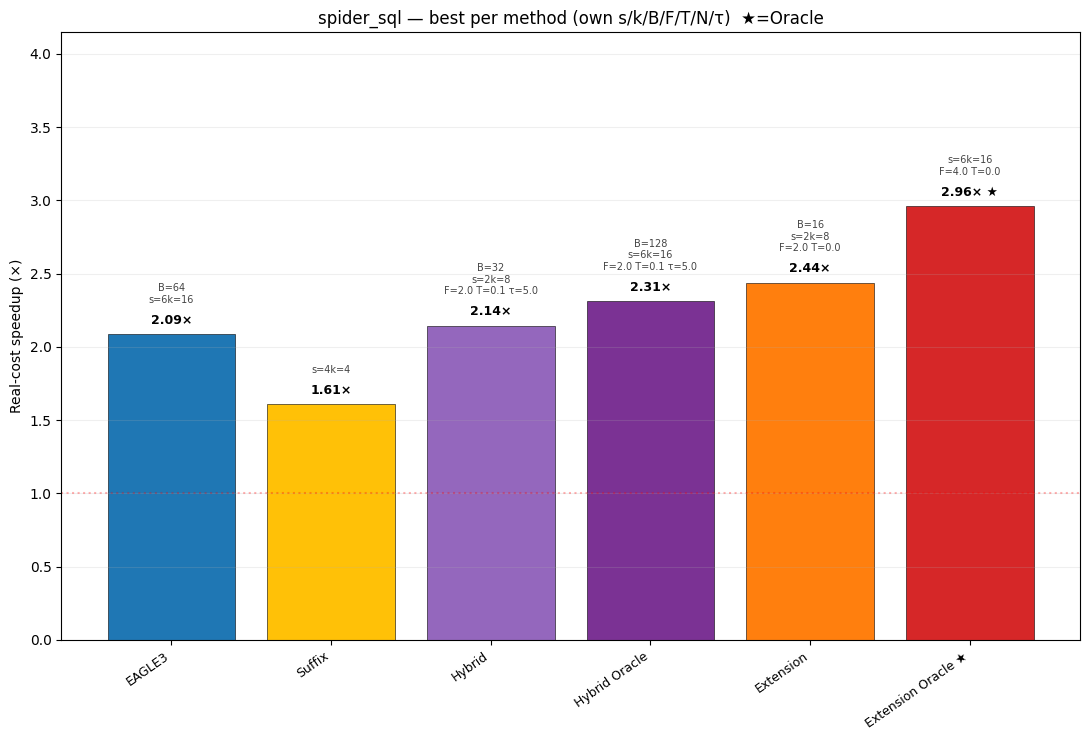

In [66]:
def _draw_speedup_chart(mdf_plot, title, hyb_fams=None, ext_fams=None):
    fig, ax = plt.subplots(figsize=(max(11, len(mdf_plot) * 1.05), 7.5))
    x = np.arange(len(mdf_plot))
    ax.bar(x, mdf_plot["speedup_real"].values, color=mdf_plot["color"].values,
           edgecolor="black", linewidth=0.4)
    for i, r in mdf_plot.iterrows():
        spd = r["speedup_real"]
        marker = " ★" if r["family"] == "extension_oracle" else ""
        ax.text(i, spd + 0.05, f"{spd:.2f}×{marker}",
                ha="center", va="bottom", fontsize=9, fontweight="bold")
        sub = bar_sub_label(r["family"], r["hp"], r["best_budget"], r.get("sk_tag"))
        if sub:
            ax.text(i, spd + 0.20, sub, ha="center", va="bottom",
                    fontsize=7, color="#444444")
    ax.set_xticks(x)
    ax.set_xticklabels(mdf_plot["pretty"], rotation=35, ha="right", fontsize=9)
    ax.set_ylabel("Real-cost speedup (×)")
    ax.set_title(title, fontsize=12)
    ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.3)
    ax.grid(axis="y", alpha=0.2)
    ax.set_ylim(top=mdf_plot["speedup_real"].max() * 1.40)
    plt.tight_layout(); plt.show()


# Hide extension variants (by_score / by_count / prune_pt) from this chart only.
# §10 (variants chart) at the bottom still shows them.
_HIDE_EXT_VARIANTS = {
    "extension_by_score", "extension_by_count", "extension_prune_pt",
    "extension_dm_by_score", "extension_dm_by_count",
}
_mdf_main = mdf_best[~mdf_best["family"].isin(_HIDE_EXT_VARIANTS)].reset_index(drop=True)

_draw_speedup_chart(
    _mdf_main, f"{WORKLOAD} — best per method (own s/k/B/F/T/N/τ)  ★=Oracle")


## 5. MAT chart — best per method (matched to speedup-best variant)

Each method's **MAT** at the same variant that maxes its speedup. Hyperparameters
are labeled above each bar (consistent with the speedup chart).

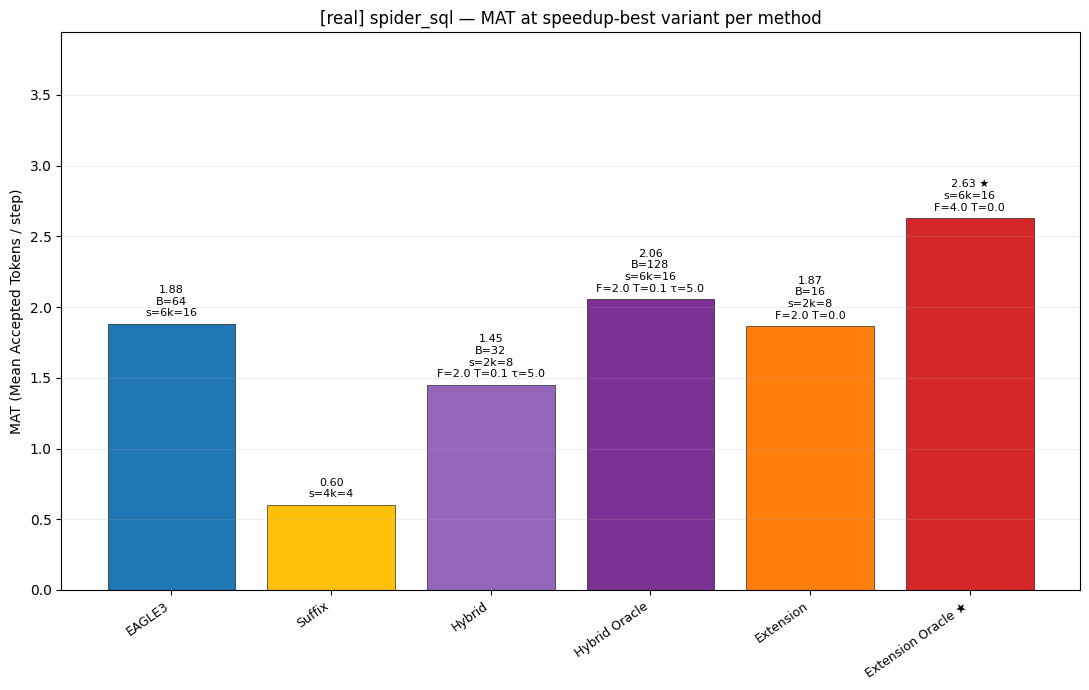

In [67]:
# Hide extension variants from this chart only.
_HIDE_EXT_VARIANTS = {
    "extension_by_score", "extension_by_count", "extension_prune_pt",
    "extension_dm_by_score", "extension_dm_by_count",
}
mdf_mat = mdf_best[~mdf_best["family"].isin(_HIDE_EXT_VARIANTS)]
mdf_mat = mdf_mat[mdf_mat["mat"] > 0].copy().reset_index(drop=True)

fig, ax = plt.subplots(figsize=(max(11, len(mdf_mat) * 1.05), 7))
ax.bar(np.arange(len(mdf_mat)), mdf_mat["mat"].values,
       color=mdf_mat["color"].values, edgecolor="black", linewidth=0.4)

for i, r in mdf_mat.iterrows():
    marker = " ★" if r["family"] == "extension_oracle" else ""
    sub = bar_sub_label(r["family"], r["hp"], r["best_budget"], r.get("sk_tag"))
    label = f"{r['mat']:.2f}{marker}" + (f"\n{sub}" if sub else "")
    ax.annotate(label, xy=(i, r["mat"]), xytext=(0, 4),
                textcoords="offset points", ha="center", va="bottom", fontsize=8)

ax.set_xticks(np.arange(len(mdf_mat)))
ax.set_xticklabels(mdf_mat["pretty"], rotation=35, ha="right", fontsize=9)
ax.set_ylabel("MAT (Mean Accepted Tokens / step)")
ax.set_title(f"[{SPEEDUP_METRIC}] {WORKLOAD} — MAT at speedup-best variant per method")
ax.grid(axis="y", alpha=0.2)
ax.margins(y=0.5)
ax.set_ylim(bottom=0)
plt.tight_layout()
plt.show()


## 6. Speedup vs MAT scatter

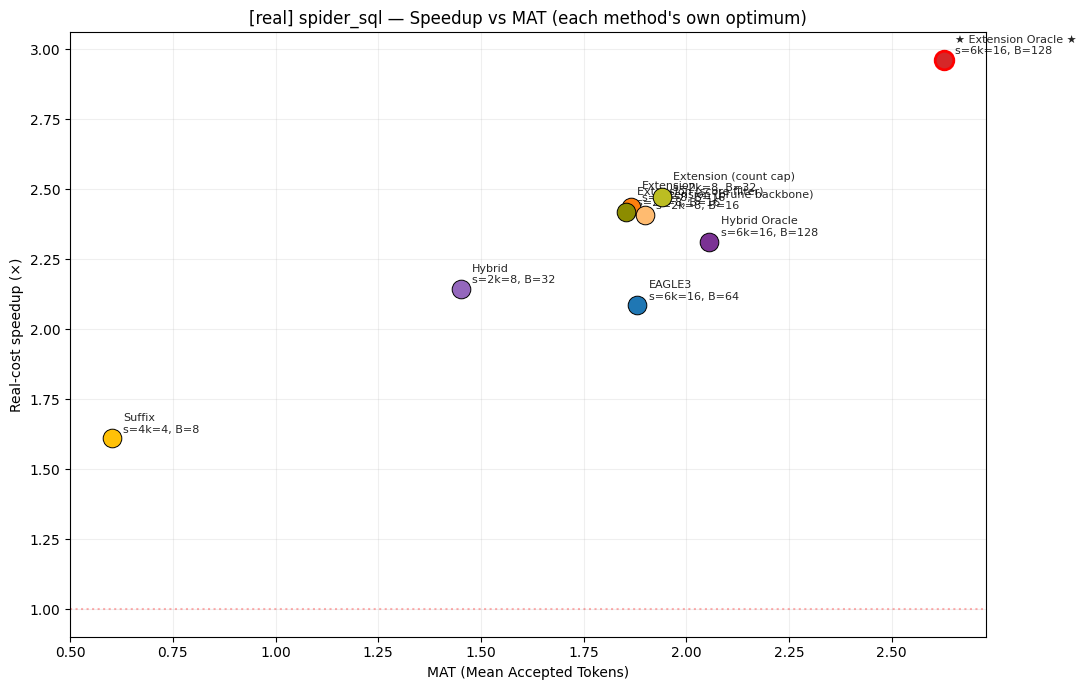

In [68]:
mdf_scatter = mdf_best[mdf_best["mat"] > 0].copy()
fig, ax = plt.subplots(figsize=(11, 7))
for _, r in mdf_scatter.iterrows():
    edge = "red" if r["family"] == "extension_oracle" else "black"
    lw = 2.0 if r["family"] == "extension_oracle" else 0.7
    ax.scatter(r["mat"], r["speedup_real"], c=r["color"], s=180,
               edgecolors=edge, linewidth=lw, zorder=5)
    label = ("★ " if r["family"] == "extension_oracle" else "") + r["pretty"]
    sub = f"{r['sk_tag']}, B={r['best_budget']}" if r['sk_tag'] != "?" else f"B={r['best_budget']}"
    ax.annotate(f"{label}\n{sub}", (r["mat"], r["speedup_real"]),
                xytext=(8, 4), textcoords="offset points", fontsize=8, alpha=0.85)
ax.axhline(y=1.0, color="red", linestyle=":", alpha=0.3)
ax.set_xlabel("MAT (Mean Accepted Tokens)")
ax.set_ylabel("Real-cost speedup (×)")
ax.set_title(f"[{SPEEDUP_METRIC}] {WORKLOAD} — Speedup vs MAT (each method's own optimum)")
ax.grid(alpha=0.2)
plt.tight_layout(); plt.show()


## 8. Per-step cost breakdown

Target forward + draft cost at each method's best budget. Vanilla shown for reference.

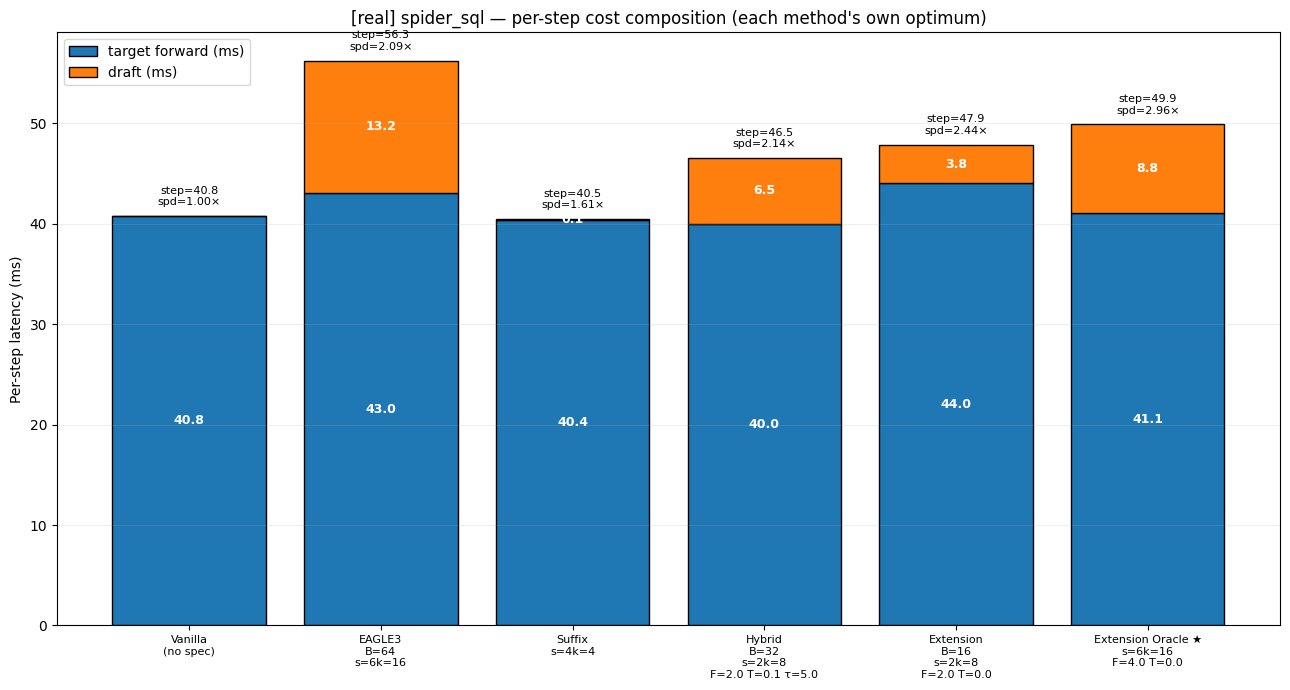

In [69]:
# Per-step cost breakdown for representative families
rep_families = ["single:eagle3", "single:suffix", "hybrid_e3",
                "extension", "extension_oracle"]
rep_rows = []
for fam in rep_families:
    rows = mdf_best[mdf_best["family"] == fam]
    if not rows.empty:
        rep_rows.append(rows.iloc[0])

labels, target_ms, draft_ms, budgets, spds = [], [], [], [], []
labels.append("Vanilla\n(no spec)"); target_ms.append(vanilla_ms); draft_ms.append(0)
budgets.append(0); spds.append(1.0)
for r in rep_rows:
    sub = bar_sub_label(r["family"], r["hp"], r["best_budget"], r.get("sk_tag"))
    lbl = r["pretty"] + (f"\n{sub}" if sub else "")
    labels.append(lbl)
    target_ms.append(r["avg_target_ms"]); draft_ms.append(r["avg_draft_ms"])
    budgets.append(r["best_budget"]); spds.append(r["speedup_real"])

x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(13, 7))
ax.bar(x, target_ms, color="#1f77b4", edgecolor="black", label="target forward (ms)")
ax.bar(x, draft_ms, bottom=target_ms, color="#ff7f0e", edgecolor="black", label="draft (ms)")
for i, (t, d, B, s) in enumerate(zip(target_ms, draft_ms, budgets, spds)):
    if t > 0:
        ax.text(i, t/2, f"{t:.1f}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
    if d > 0:
        ax.text(i, t+d/2, f"{d:.1f}", ha="center", va="center",
                color="white", fontweight="bold", fontsize=9)
    total = t + d
    if total > 0:
        ax.text(i, total + max(target_ms+draft_ms)*0.02,
                f"step={total:.1f}\nspd={s:.2f}×",
                ha="center", va="bottom", fontsize=8)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("Per-step latency (ms)")
ax.set_title(f"[{SPEEDUP_METRIC}] {WORKLOAD} — per-step cost composition (each method's own optimum)")
ax.legend(loc="upper left"); ax.grid(axis="y", alpha=0.2)
plt.tight_layout(); plt.show()


## 9. Implementation notes — current methods

All methods live in `simulation/evaluation/run_tree_oracle_sim.py`. Cost model:
- `step_cost = target_forward(ext_size) + draft_cost`
- `draft_cost = eagle3_draft(B) + n_actual_suffix_calls × suffix_speculate_ms` (sequential)
- `n_actual_suffix_calls` is dynamically counted (not heuristic)

### Baselines (single proposer)
| method | tree |
|---|---|
| `single:eagle3` | EAGLE3 backbone, top-B by path_prob |
| `single:suffix` | live `SuffixDecodingCache.speculate()` (aggressive params) |
| `single:draft_model` | length-`min(B, 16)` chain from draft LM |

### Hybrid (paper SuffixDecoding)
| method | gate |
|---|---|
| `hybrid_e3:t` | suffix if score ≥ t (paper-faithful F=1.0, T=0.1) else EAGLE3 |
| `hybrid_e3_sfx:F:T:N:t` | NEW — same gate but custom suffix params (F, T, N) |
| `hybrid_dm:t` | suffix if score ≥ t else draft-model chain |

### Extension (eagle3 base + suffix grafts at every node)
| method | accounting |
|---|---|
| `extension` | deployable, ext_size = full tree |
| `extension_oracle` ★ | oracle, ext_size = base + accepted_suffix |
| `extension_sfx:F:T:N` | custom suffix params (deployable) |
| `extension_sfx_oracle:F:T:N` | custom suffix params (oracle) |
| `extension_prune_pt:t` | drop base nodes with path_p_t < t |
| `extension_prune_pt_oracle:t` | same + oracle accounting |
| `extension_hybrid:t` | gate suffix-only / ext fallback (deployable) |
| `extension_hybrid_oracle:t` | same gate + oracle accounting on ext branch |

### Forbidden (per `project_50pct_gap_goal.md`)
| method | reason |
|---|---|
| `extension_oracle_path` | path-only accounting unrealistic (verify pays for whole tree) |
| `extension_hybrid_perfect_oracle` | per-step ORACLE choice between paths is unrealistic |


## 10. Cross-sim method-optimum-vs-method-optimum

Each method picks its own best (s, k, B, threshold) across **all** discovered sims for the
selected workload. This is the FAIRNESS-correct comparison per
`feedback_method_optimum_independent.md`: never pin both methods to the same reslice.

In [70]:
# Same as the summary table (cell §3), repeated here for clarity:
# every method picked its OWN best (s, k, B, F, T, N, threshold) across all
# discovered sims for the workload. No cell pins methods to a single sim.
print(f"=== {WORKLOAD} — per-method cross-sim optimum ===\n")
print(f"{'method':<35} {'variant':<46} {'reslice':<10} {'B':>4} {'spd_real':>9}")
print("-" * 110)
for _, r in mdf_best.iterrows():
    print(f"{r['pretty']:<35} {r['method'][:44]:<46} {r['sk_tag']:<10} {r['best_budget']:>4} "
          f"{r['speedup_real']:>9.3f}")

# Final headline
ext_or = mdf_best[mdf_best["family"] == "extension_oracle"]
hyb = mdf_best[mdf_best["family"] == "hybrid_e3"]
if len(ext_or) and len(hyb):
    e = ext_or.iloc[0]; h = hyb.iloc[0]
    gap = (e["speedup_real"] / h["speedup_real"] - 1) * 100
    print(f"\n★ HEADLINE GAP: {gap:+.2f}%   (50% target gap = {50 - gap:+.2f}%)")


=== spider_sql — per-method cross-sim optimum ===

method                              variant                                        reslice       B  spd_real
--------------------------------------------------------------------------------------------------------------
EAGLE3                              eagle3                                         s=6k=16      64     2.086
Suffix                              suffix                                         s=4k=4        8     1.611
Hybrid                              hybrid_e3_f2.0_t0.1_th5.0                      s=2k=8       32     2.145
Hybrid Oracle                       hybrid_oracle_f2.0_t0.1_th5.0                  s=6k=16     128     2.313
Extension                           extension_f2.0_t0.0                            s=2k=8       16     2.439
Extension (score filter)            extension_by_score_t3.0                        s=2k=8       16     2.419
Extension (count cap)               extension_by_count_r2.0                

## Method comparison — current run

All 8 method families read from `simulation/results/explorations/` (legacy result dirs are archived under `legacy_260429/` and not consulted).

Each family picks its OWN best (s, k, B, F, T, τ) — fair method-optimum view.


=== spider_sql — variants + oracles (each picks own s, k, B, hyperparams) ===
method                              variant                                        reslice             B       spd    mat hp                       
---------------------------------------------------------------------------------------------------------------------------------------------------------------------
Extension                           extension_f2.0_t0.0                            s=2k=8             16     2.439   1.87 F=2.0 T=0.0              
Extension (score filter)            extension_by_score_t3.0                        s=2k=8             16     2.419   1.85 s≥3.0                    
Extension (count cap)               extension_by_count_r2.0                        s=2k=8             32     2.474   1.94 r=2.0                    
Extension (prune backbone)          extension_prune_pt_t0.01                       s=2k=8             16     2.409   1.90 pt=0.01                  
Extension Oracle

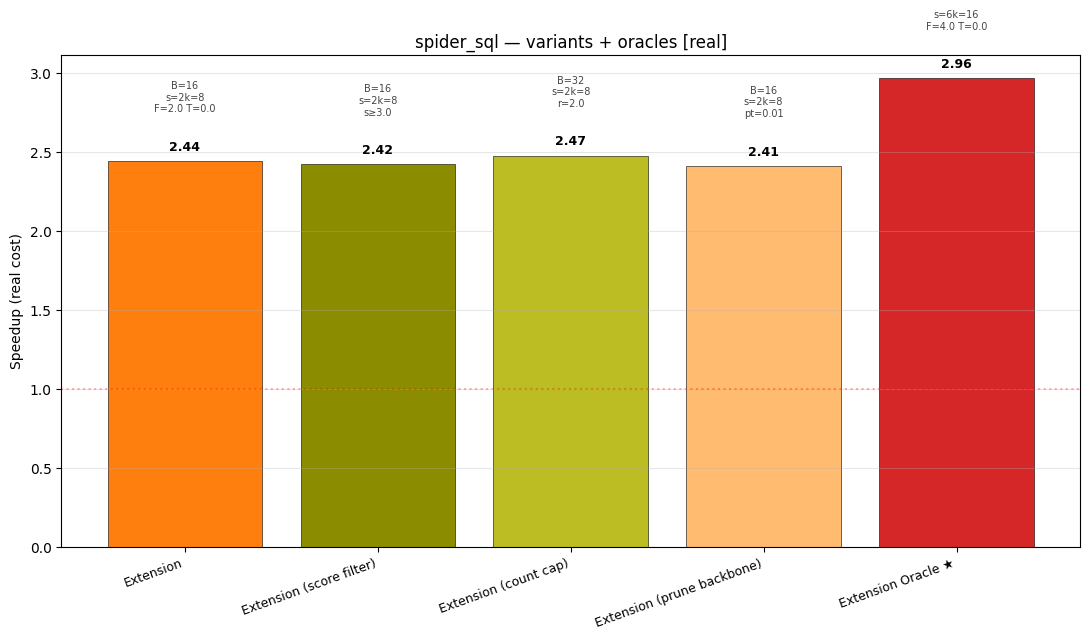

In [71]:
# Uses SPEEDUP_METRIC / _METRIC_SUFFIX from the top config cell.
_metric_suffix = _METRIC_SUFFIX

# All 8 method families read from current explorations/ (single source).
# (Legacy result dirs were archived to legacy_260429/ and are not consulted.)
import re as _re

CURRENT_DIR = Path('../results/explorations')
# Variant chart shows ONLY extension-family methods (eagle3-base + dm-base).
# Hybrids and single proposers are excluded by design — see §3-§6 for those.
_ENROLLED_FULL = [
    'extension', 'extension_oracle',
    'extension_by_score', 'extension_by_count', 'extension_prune_pt',
    'extension_dm', 'extension_dm_oracle',
    'extension_dm_by_score', 'extension_dm_by_count',
]
ENROLLED_FAMILIES = [f for f in _ENROLLED_FULL if f not in HIDDEN_FAMILIES]

_v_records = []
if not CURRENT_DIR.exists():
    print(f'No current dir: {CURRENT_DIR}')
else:
    for p in CURRENT_DIR.glob('*.json'):
        if not _is_sim_json(p):
            continue
        info = _parse_filename(p.stem)
        wl = info['workload']
        if wl != WORKLOAD and not (WORKLOAD == 'longbench_lcc' and wl == 'lcc') \
                and not (WORKLOAD == 'longbench_repobench' and wl == 'repobench'):
            continue
        try:
            with open(p) as f:
                dd = json.load(f)
        except Exception:
            continue
        df_v = pd.DataFrame(dd['latency']['budget_sweep'])
        sk = f"s={info['steps']}k={info['topk']}" if info['steps'] else '?'
        for col in df_v.columns:
            if not col.endswith(_metric_suffix):
                continue
            mn = col[:-len(_metric_suffix)]
            if mn.endswith('_always') or is_forbidden(mn):
                continue
            mfam = family(mn)
            if mfam not in ENROLLED_FAMILIES:
                continue
            for idx in df_v.index:
                spd = df_v[col].iloc[idx]
                if pd.isna(spd):
                    continue
                B = int(df_v['budget'].iloc[idx])
                mat = float(df_v.get(f'{mn}_mat',
                                      pd.Series([np.nan])).iloc[idx]) \
                    if f'{mn}_mat' in df_v.columns else 0
                _v_records.append({
                    'method': mn, 'family': mfam,
                    'pretty': PRETTY_LABEL.get(mfam, mfam),
                    'sim': p.stem, 'sk_tag': sk, 'best_budget': B,
                    'speedup': float(spd), 'mat': mat,
                    'hp': hyperparam_str(mn),
                })

v_all = pd.DataFrame(_v_records)
if v_all.empty:
    print(f'No variant data found for WORKLOAD={WORKLOAD}')
    raise SystemExit

# Per-family best (each family picks its OWN s, k, B, F, T, τ)
v_best = (v_all.sort_values('speedup', ascending=False)
                .drop_duplicates(subset='family')
                .reset_index(drop=True))
v_best['color'] = v_best['family'].map(FAMILY_COLOR).fillna('#cccccc')

# Order: hybrid_e3 → hybrid_oracle → extension → variants → extension_oracle
_order_full = ['extension',
               'extension_by_score', 'extension_by_count', 'extension_prune_pt',
               'extension_oracle',
               'extension_dm',
               'extension_dm_by_score', 'extension_dm_by_count',
               'extension_dm_oracle']
_order = [f for f in _order_full if f not in HIDDEN_FAMILIES]
v_best['_o'] = v_best['family'].map(
    {f: i for i, f in enumerate(_order)}).fillna(99)
v_best = v_best.sort_values('_o').drop(columns='_o').reset_index(drop=True)

print(f'=== {WORKLOAD} — variants + oracles (each picks own s, k, B, hyperparams) ===')
print(f"{'method':<35} {'variant':<46} {'reslice':<10} {'B':>10} {'spd':>9} {'mat':>6} {'hp':<25}")
print('-' * 165)
for _, r in v_best.iterrows():
    bv = r['best_budget']
    b_str = bv if isinstance(bv, str) else str(bv)
    print(f"{r['pretty']:<35} {r['method'][:44]:<46} {r['sk_tag']:<10} "
          f"{b_str:>10} {r['speedup']:>9.3f} {r['mat']:>6.2f} {r.get('hp', ''):<25}")

# Bar plot — Speedup
fig, ax = plt.subplots(figsize=(max(11, len(v_best) * 1.05), 6.5))
x = np.arange(len(v_best))
ax.bar(x, v_best['speedup'].values, color=v_best['color'].values,
       edgecolor='black', linewidth=0.4)
for i, r in v_best.iterrows():
    spd = r['speedup']
    ax.text(i, spd + 0.05, f"{spd:.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    sub_parts = []
    bv = r['best_budget']
    # Skip B label for extension_oracle (per-step picker)
    if r['family'] != 'extension_oracle':
        sub_parts.append(f"B={bv}")
    if r['sk_tag'] != '?':
        sub_parts.append(r['sk_tag'])
    if r.get('hp'):
        sub_parts.append(r['hp'])
    ax.text(i, spd + 0.30, '\n'.join(sub_parts), ha='center', va='bottom',
            fontsize=7, color='#444444')
ax.axhline(y=1.0, color='red', linestyle=':', alpha=0.3)
ax.set_xticks(x)
ax.set_xticklabels(v_best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel(f'Speedup ({SPEEDUP_METRIC} cost)')
ax.set_title(f'{WORKLOAD} — variants + oracles [{SPEEDUP_METRIC}]')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


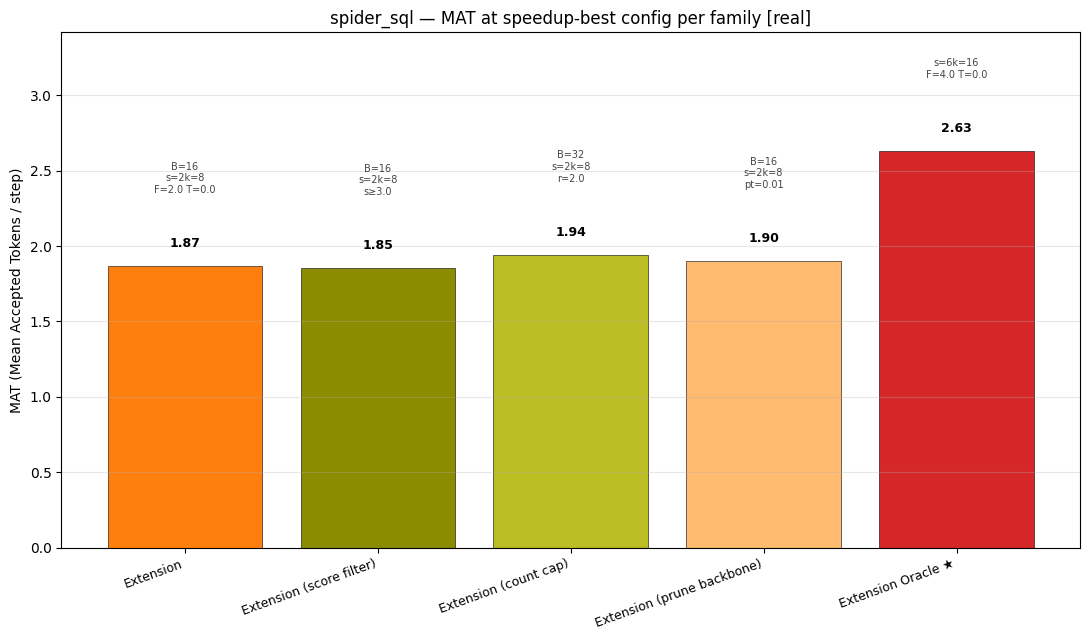

In [72]:
# MAT at speedup-best config per family (uses v_best from above cell)
fig, ax = plt.subplots(figsize=(max(11, len(v_best) * 1.05), 6.5))
x = np.arange(len(v_best))
ax.bar(x, v_best['mat'].values, color=v_best['color'].values,
       edgecolor='black', linewidth=0.4)
for i, r in v_best.iterrows():
    mat = r['mat']
    ax.text(i, mat + 0.04 * v_best['mat'].max(), f"{mat:.2f}",
            ha='center', va='bottom', fontsize=9, fontweight='bold')
    sub_parts = []
    bv = r['best_budget']
    if r['family'] != 'extension_oracle':
        sub_parts.append(f"B={bv}")
    if r['sk_tag'] != '?':
        sub_parts.append(r['sk_tag'])
    if r.get('hp'):
        sub_parts.append(r['hp'])
    ax.text(i, mat + 0.18 * v_best['mat'].max(), '\n'.join(sub_parts),
            ha='center', va='bottom', fontsize=7, color='#444444')
ax.set_xticks(x)
ax.set_xticklabels(v_best['pretty'].values, rotation=20, ha='right', fontsize=9)
ax.set_ylabel('MAT (Mean Accepted Tokens / step)')
ax.set_title(f'{WORKLOAD} — MAT at speedup-best config per family [{SPEEDUP_METRIC}]')
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(top=v_best['mat'].max() * 1.30)
plt.tight_layout()
plt.show()
